# Processamento de Sinais I — Aula Prática 2
## Questão 8 — Amostragem na frequência de Nyquist e reconstrução

Sinal analisado:
$$x(t) = cos(2000\pi t) + sin(5000\pi t)$$

Informações:
- Aproximação contínua gerada com `f_s = 10 MHz`
- Duração: 10 ms
- Frequências presentes: 1000 Hz e 2500 Hz
- Frequência de Nyquist: 5000 Hz

## Importar bibliotecas e carregar a função de espectro

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy import signal

def load_calculate_spectrum():
    notebook_path = Path('../tools/calculate_spectrum.ipynb')
    notebook = json.loads(notebook_path.read_text(encoding='utf-8'))

    namespace = {}
    for cell in notebook['cells']:
        if cell.get('cell_type') != 'code':
            continue

        source = ''.join(cell.get('source', []))
        exec(source, namespace)
        if 'calculate_spectrum' in namespace:
            return namespace['calculate_spectrum']

    raise RuntimeError('calculate_spectrum() nao encontrada em ../tools/calculate_spectrum.ipynb')

calculate_spectrum = load_calculate_spectrum()

plt.style.use('seaborn-v0_8-whitegrid')

def to_float_mono(data):
    data = np.asarray(data)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        data = data.astype(np.float64) / np.iinfo(data.dtype).max
    else:
        data = data.astype(np.float64)
    peak = np.max(np.abs(data))
    if peak > 1:
        data = data / peak
    return data


def show_audio(audio, rate, label):
    print(label)
    display(Audio(audio, rate=rate))


def plot_spectrum(signal_in, sampling_frequency, title, max_frequency=None):
    freqs, amps = calculate_spectrum(signal_in, sampling_frequency, single_sided=True)
    plt.figure(figsize=(12, 4))
    plt.plot(freqs, amps)
    if max_frequency is not None:
        plt.xlim(0, max_frequency)
    plt.title(title)
    plt.xlabel('Frequencia (Hz)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    return freqs, amps


## Gerar a aproximação contínua e calcular seu espectro

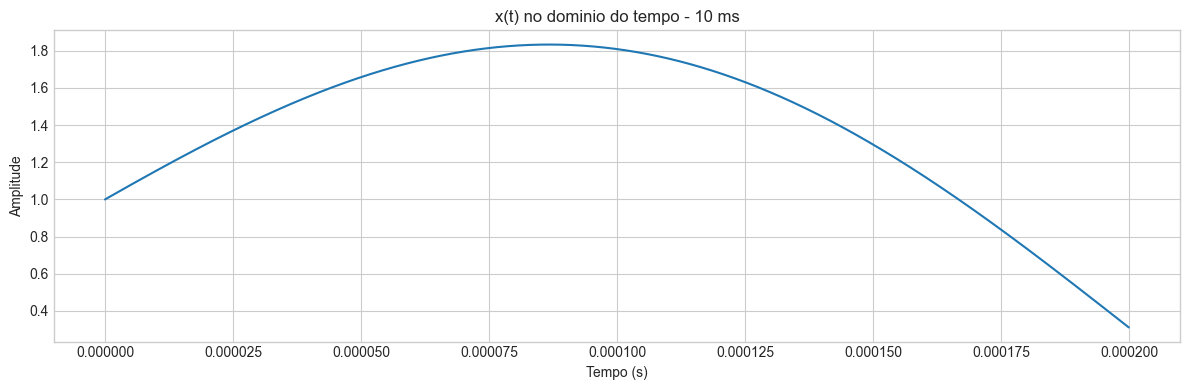

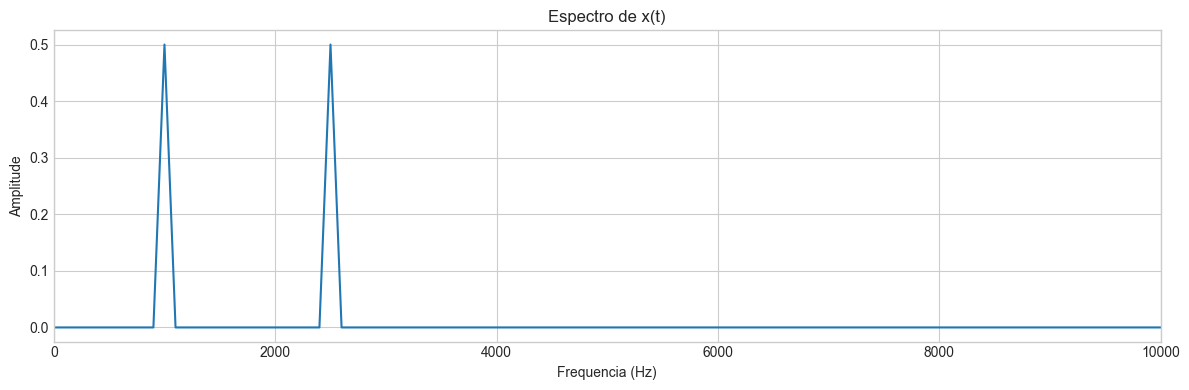

In [2]:
fs_cont = 10_000_000
duracao = 0.01

t = np.linspace(0, duracao, int(fs_cont * duracao), endpoint=False)
x_t = np.cos(2000 * np.pi * t) + np.sin(5000 * np.pi * t)

plt.figure(figsize=(12, 4))
plt.plot(t[:2000], x_t[:2000])
plt.title('x(t) no dominio do tempo - 10 ms')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.tight_layout()

plot_spectrum(x_t, fs_cont, 'Espectro de x(t)', max_frequency=10_000)
plt.show()


## Amostrar na frequência de Nyquist

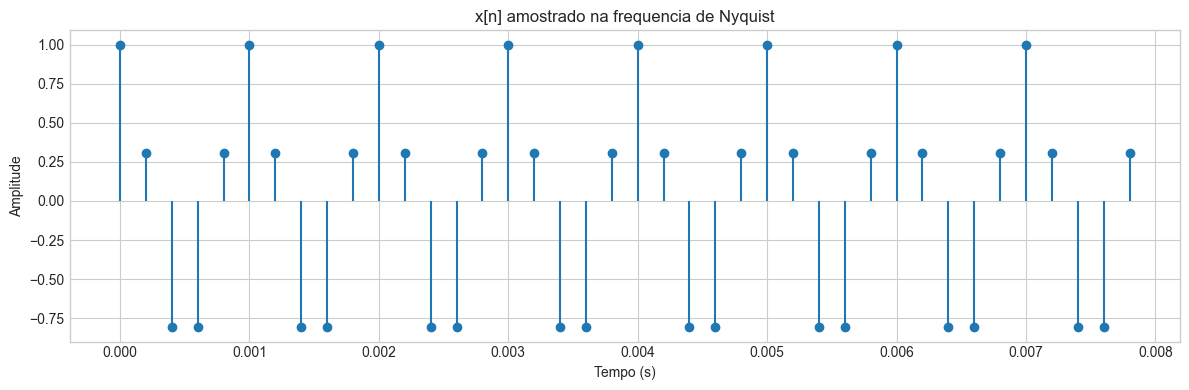

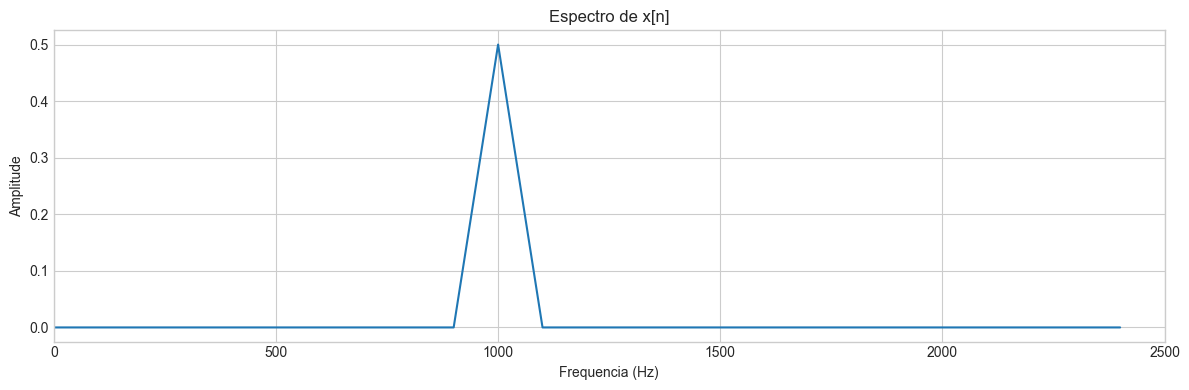

In [3]:
fs_nyquist = 5_000
n = np.arange(0, duracao, 1 / fs_nyquist)
x_n = np.cos(2000 * np.pi * n) + np.sin(5000 * np.pi * n)

plt.figure(figsize=(12, 4))
plt.stem(n[:40], x_n[:40], basefmt=' ')
plt.title('x[n] amostrado na frequencia de Nyquist')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.tight_layout()

plot_spectrum(x_n, fs_nyquist, 'Espectro de x[n]', max_frequency=fs_nyquist / 2)
plt.show()


## Reconstruir com interpolação sinc e pulso retangular (ZOH)

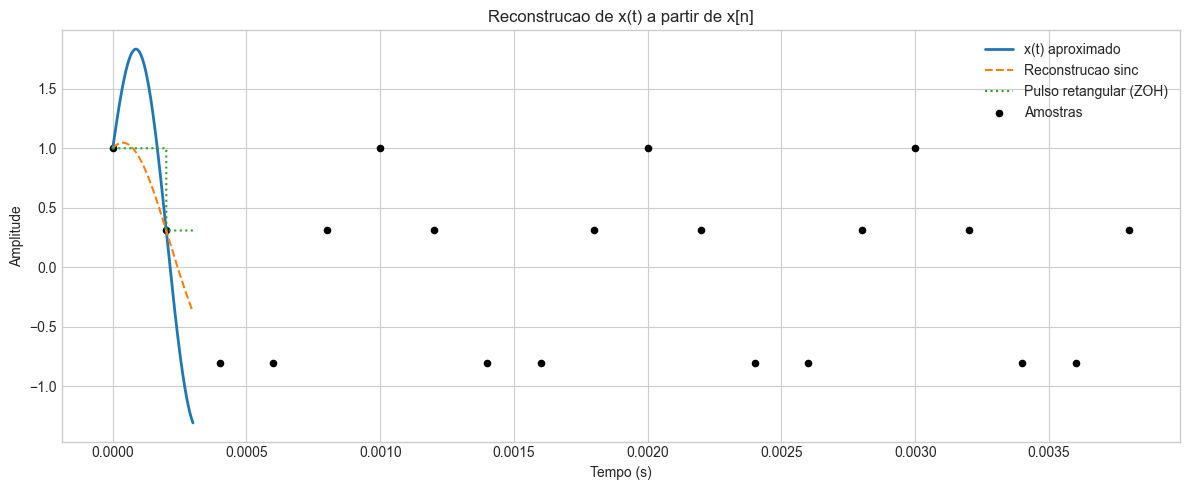

In [4]:
def sinc_interp(samples, sample_times, query_times):
    Ts = sample_times[1] - sample_times[0]
    sinc_matrix = np.sinc((query_times[:, None] - sample_times[None, :]) / Ts)
    return sinc_matrix @ samples


def zoh_interp(samples, sample_times, query_times):
    idx = np.searchsorted(sample_times, query_times, side='right') - 1
    idx = np.clip(idx, 0, len(samples) - 1)
    return samples[idx]


x_sinc = sinc_interp(x_n, n, t)
x_zoh = zoh_interp(x_n, n, t)

plt.figure(figsize=(12, 5))
plt.plot(t[:3000], x_t[:3000], label='x(t) aproximado', linewidth=2)
plt.plot(t[:3000], x_sinc[:3000], '--', label='Reconstrucao sinc')
plt.plot(t[:3000], x_zoh[:3000], ':', label='Pulso retangular (ZOH)')
plt.scatter(n[:20], x_n[:20], color='black', s=20, label='Amostras')
plt.title('Reconstrucao de x(t) a partir de x[n]')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()


## Comentários

Como a maior frequência do sinal é 2500 Hz, a frequência de Nyquist é 5000 Hz. A amostragem nessa taxa é suficiente para representar o sinal sem aliasing ideal.

A reconstrução por sinc se aproxima melhor do sinal original, pois corresponde à interpolação ideal de banda limitada. Já a reconstrução por pulso retangular apresenta aspecto em degraus e maior distorção temporal.